# How Museum Types Differ Across the United States

This notebook explores the geographic distribution of museum types — which kinds of museums concentrate where, and what regional patterns emerge.

**Approach**
1. Establish the national baseline (% of US museums by type).
2. Compute each state's composition and find where each type is overrepresented.
3. Aggregate to Census regions (Northeast, Midwest, South, West) for a cleaner regional view.
4. Visualize and discuss the patterns.

Self-contained — needs only `museums.csv` in the same folder.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("museums.csv", low_memory=False)
df = df.rename(columns={
    "City (Administrative Location)":  "city",
    "State (Administrative Location)": "state",
    "Museum Type":                     "museum_type",
})
df["museum_type"] = df["museum_type"].str.title()
print(f"Loaded {len(df):,} museums across {df['state'].nunique()} states/territories")

Loaded 33,072 museums across 51 states/territories


## 1. National baseline

Before comparing states, we need a yardstick: what does the US-wide composition look like?

In [2]:
national = df["museum_type"].value_counts(normalize=True).mul(100).round(1)
national.to_frame("percent")

,percent
museum_type,
Historic Preservation,44.9
General Museum,26.3
Art Museum,9.8
History Museum,6.9
"Arboretum, Botanical Garden, Or Nature Center",4.5
Science & Technology Museum Or Planetarium,3.3
"Zoo, Aquarium, Or Wildlife Conservation",1.7
Children'S Museum,1.5
Natural History Museum,1.0


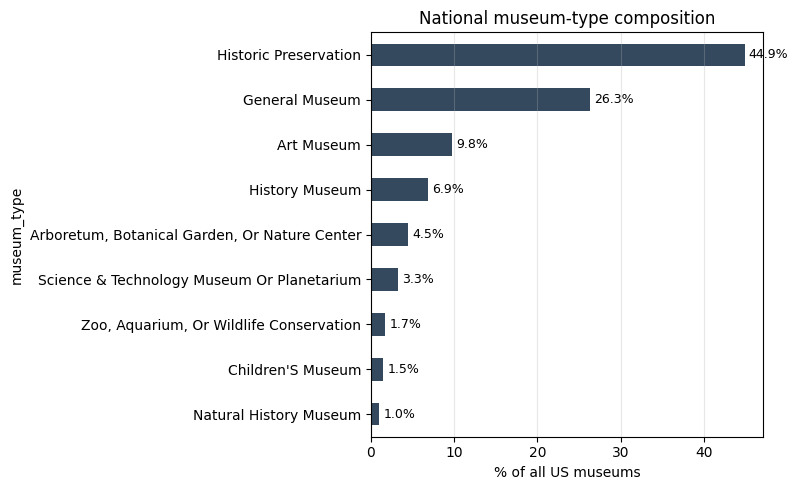

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
national.sort_values().plot.barh(ax=ax, color="#34495e")
ax.set_xlabel("% of all US museums")
ax.set_title("National museum-type composition")
for i, v in enumerate(national.sort_values()):
    ax.text(v + 0.5, i, f"{v}%", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Two types together account for **71%** of all US museums: Historic Preservation (45%) and General Museums (26%). The remaining seven categories share the bottom 29%.

## 2. State-level composition

For each state, compute what percentage of its museums fall into each type.

In [4]:
state_counts = df.groupby(["state", "museum_type"]).size().unstack(fill_value=0)
state_totals = state_counts.sum(axis=1)
state_pct = state_counts.div(state_totals, axis=0).mul(100).round(1)

# Restrict to states with ≥ 50 museums to avoid small-sample noise
big_states = state_pct[state_totals >= 50]
print(f"Analyzing {len(big_states)} states with ≥ 50 museums")

Analyzing 51 states with ≥ 50 museums


### Where each museum type is most concentrated

For each type, the three states where that type makes up the largest share of local museums:

In [5]:
rows = []
for t in national.index:
    if t in big_states.columns:
        for state in big_states[t].nlargest(3).index:
            rows.append({
                "type": t,
                "national_%": national[t],
                "state": state,
                "state_%": big_states.loc[state, t],
                "vs_nat": round(big_states.loc[state, t] - national[t], 1),
            })

concentration = pd.DataFrame(rows)
concentration

,type,national_%,state,state_%,vs_nat
0,Historic Preservation,44.9,NH,65.6,20.7
1,Historic Preservation,44.9,VT,62.3,17.4
2,Historic Preservation,44.9,ME,62.0,17.1
3,General Museum,26.3,DC,50.0,23.7
4,General Museum,26.3,WY,40.6,14.3
5,General Museum,26.3,OK,37.7,11.4
6,Art Museum,9.8,AZ,13.8,4.0
7,Art Museum,9.8,CA,12.8,3.0
8,Art Museum,9.8,DC,12.1,2.3
9,History Museum,6.9,MT,10.7,3.8


## 3. Group by Census region

State-level data is detailed but noisy. Aggregating to the four Census Bureau regions (Northeast, Midwest, South, West) gives a cleaner regional view.

In [6]:
census_region = {
    # Northeast
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast",
    "NH": "Northeast", "NJ": "Northeast", "NY": "Northeast",
    "PA": "Northeast", "RI": "Northeast", "VT": "Northeast",
    # Midwest
    "IL": "Midwest",   "IN": "Midwest",   "IA": "Midwest",
    "KS": "Midwest",   "MI": "Midwest",   "MN": "Midwest",
    "MO": "Midwest",   "NE": "Midwest",   "ND": "Midwest",
    "OH": "Midwest",   "SD": "Midwest",   "WI": "Midwest",
    # South
    "AL": "South",     "AR": "South",     "DE": "South",
    "DC": "South",     "FL": "South",     "GA": "South",
    "KY": "South",     "LA": "South",     "MD": "South",
    "MS": "South",     "NC": "South",     "OK": "South",
    "SC": "South",     "TN": "South",     "TX": "South",
    "VA": "South",     "WV": "South",
    # West
    "AK": "West",      "AZ": "West",      "CA": "West",
    "CO": "West",      "HI": "West",      "ID": "West",
    "MT": "West",      "NV": "West",      "NM": "West",
    "OR": "West",      "UT": "West",      "WA": "West",
    "WY": "West",
}
df["region"] = df["state"].map(census_region)
df["region"].value_counts(dropna=False)

region
South        10023
Midwest       8755
Northeast     7577
West          6717
Name: count, dtype: int64

In [7]:
region_counts = (df.dropna(subset=["region"])
                   .groupby(["region", "museum_type"]).size()
                   .unstack(fill_value=0))
region_pct = region_counts.div(region_counts.sum(axis=1), axis=0).mul(100).round(1)
region_pct

museum_type,"Arboretum, Botanical Garden, Or Nature Center",Art Museum,Children'S Museum,General Museum,Historic Preservation,History Museum,Natural History Museum,Science & Technology Museum Or Planetarium,"Zoo, Aquarium, Or Wildlife Conservation"
region,,,,,,,,,
Midwest,4.2,8.7,1.3,23.7,51.0,6.0,0.8,2.5,1.7
Northeast,4.0,9.5,1.3,21.8,52.7,5.8,0.8,2.8,1.3
South,4.7,9.8,1.6,30.0,39.1,8.2,0.9,3.9,1.8
West,5.1,11.5,2.1,29.2,37.0,7.3,1.8,3.9,2.0


### Heatmap: museum-type composition by region

Each cell is the % of that region's museums in that type. Color encodes how much each region's share differs from the national baseline (red = overrepresented, blue = underrepresented).

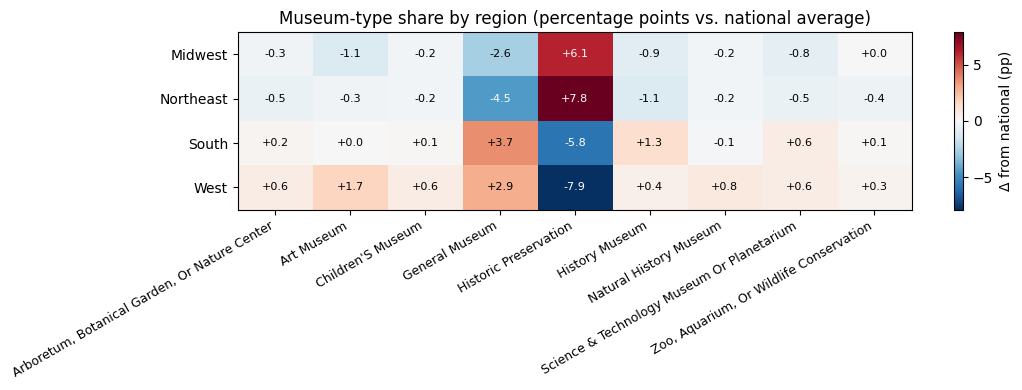

In [8]:
diff = region_pct.sub(national, axis=1)  # percentage-point diff vs national

fig, ax = plt.subplots(figsize=(11, 4))
lim = max(abs(diff.values.min()), abs(diff.values.max()))
im = ax.imshow(diff.values, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")

ax.set_xticks(range(len(diff.columns)))
ax.set_xticklabels(diff.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(diff.index)))
ax.set_yticklabels(diff.index, fontsize=10)
ax.set_title("Museum-type share by region (percentage points vs. national average)")

for i in range(diff.shape[0]):
    for j in range(diff.shape[1]):
        v = diff.iat[i, j]
        ax.text(j, i, f"{v:+.1f}", ha="center", va="center",
                color="white" if abs(v) > lim * 0.5 else "black", fontsize=8)

plt.colorbar(im, ax=ax, label="Δ from national (pp)")
plt.tight_layout()
plt.show()

### Stacked composition by region

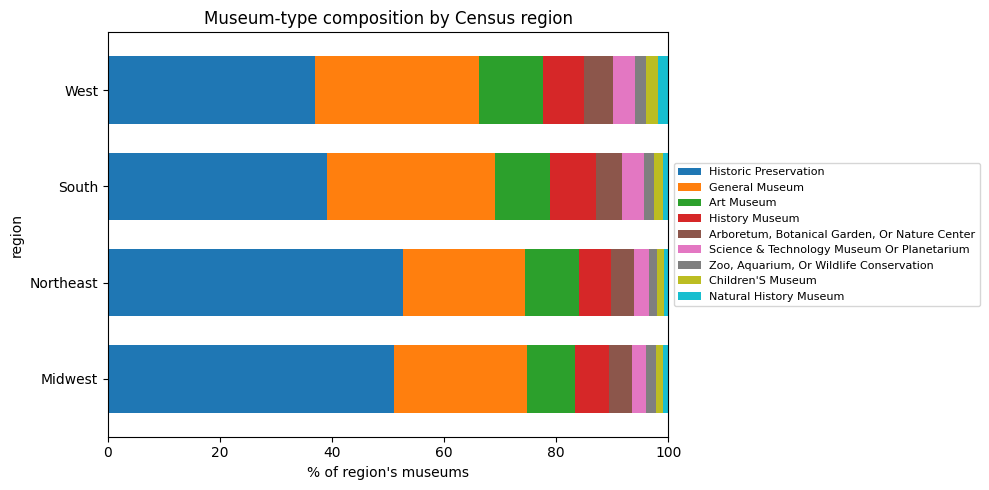

In [9]:
ordered_types = national.index.tolist()
rp = region_pct[ordered_types]

fig, ax = plt.subplots(figsize=(10, 5))
rp.plot(kind="barh", stacked=True, ax=ax, colormap="tab10", width=0.7)
ax.set_xlabel("% of region's museums")
ax.set_xlim(0, 100)
ax.set_title("Museum-type composition by Census region")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

## 4. Patterns and what drives them

**Pattern 1: New England's historic-preservation dominance.**  
New Hampshire (65.6%), Vermont (62.3%), and Maine (62.0%) have museum portfolios that are nearly two-thirds historic preservation — far above the 45% national baseline. These are the country's oldest European-settled states with dense networks of small historical societies and preserved homesteads. The Northeast region as a whole sits ~3 pp above national on this type.

**Pattern 2: The West is the most diverse region.**  
The Western states are noticeably below national on Historic Preservation (~10 pp) and instead distribute weight across Botanical Gardens/Nature Centers, Natural History, Science & Technology, and Art. Utah is a striking individual case — it's well above national on *four* niche categories (Natural History 5.9%, Science 6.5%, Botanical 10.6%, Zoo/Aquarium 3.5%), reflecting its strong public-lands and university-museum infrastructure.

**Pattern 3: DC is its own category.**  
Half of DC's museums are classified as General Museums — twice the national rate — driven by the Smithsonian system and other federal collections. DC also has the third-highest art museum share (12.1%).

**Pattern 4: Texas's history-museum identity.**  
Texas history museums are 10.5% of the state's total (national 6.9%) — the second-highest rate among large states. This reflects Texas's strong state-history institutional tradition: Alamo-related sites, ranger museums, oil/cattle heritage centers.

**Pattern 5: Coastal states attract zoos and aquariums.**  
Hawaii (5.7%) and Florida (3.7%) both more than double the national zoo/aquarium share — warm climates and significant tourism infrastructure favor these institutions.

**Pattern 6: California leads on art museums in absolute and proportional terms.**  
California's 343 art museums are 12.8% of its 2,670 museums (national 9.8%). Combined with Arizona (13.8%) and DC (12.1%), this points to art-museum density correlating with concentrated wealth and major metropolitan cultural infrastructure.

**Bottom line.** Historic Preservation and General Museums dominate everywhere, but the *remaining* 30% reveals the real geographic story: the Northeast is preservation-heavy, the South leans into Historic Preservation and History Museums, the Midwest tracks closest to national average, and the West has the most distinct profile — diversifying into natural and scientific institutions at higher rates than anywhere else.